In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv
/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).xlsx


# 1. Preparation

## 1.1. Library

In [2]:
import re
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

## 1.2. Data Acq. - Get data from dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv")

In [4]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en


In [5]:
df = df[df["country"] == "Indonesia"]

## 1.3. Data Engineering - Extract city from `Observ` column

The `observ` column contains semi-structured text with a consistent pattern.
We can leverage this pattern using regular expressions to extract the city name from each observation.

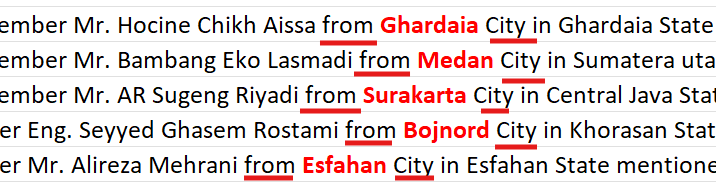


In [6]:
def extract_city(text):
    text = text.lower()
    
    match = re.search(r'from (.*?) city', text)
    if match:
        return match.group(1).strip().title()
    
    return None

In [7]:
df['city'] = df['observ'].apply(extract_city)

In [8]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source,city
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Medan
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Surakarta
17,2013-03-13,Indonesia,1,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Medan
18,2013-03-13,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Surakarta
51,2012-03-23,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1433,https://astronomycenter.net/icop/jua33.html?l=en,Surakarta


city
Surakarta          251
Medan               65
Ponorogo            25
Barus                6
Lembang              3
Kupang               3
Tapanuli Tengah      2
Sutakarta            1
Bandung              1
سوكابومي             1
Name: count, dtype: int64


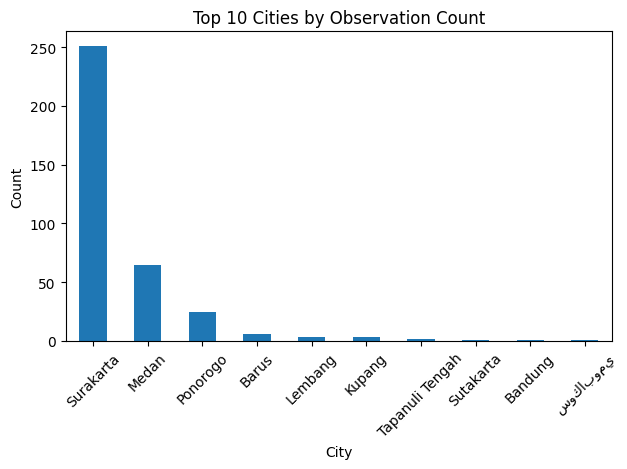

In [9]:
top_n = 10
top_cities = df['city'].value_counts().head(top_n)
print(top_cities)

# Visualize top city
top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Observation Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 1.4. Data Acq. - Get Lat & Long data based on `Country` & `City` column 

In [10]:
geolocator = Nominatim(user_agent="geo")

In [11]:
# def get_lat_lon(row):
#     query = f"{row['city']}, {row['country']}"
#     # print(query)
#     try:
#         loc = geolocator.geocode(query)
#         if loc:
#             return pd.Series([loc.latitude, loc.longitude])
#     except:
#         pass
    
#     return pd.Series([None, None])

# df[["lat", "lon"]] = df.apply(get_lat_lon, axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 363 entries, 1 to 5683
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         363 non-null    object
 1   country      363 non-null    object
 2   visible      363 non-null    int64 
 3   weather      363 non-null    object
 4   observ       363 non-null    object
 5   hijri_month  363 non-null    object
 6   hijri_year   363 non-null    int64 
 7   source       363 non-null    object
 8   city         363 non-null    object
dtypes: int64(2), object(7)
memory usage: 28.4+ KB
